In [1]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import tensorflow.keras.backend as K
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
def dice_loss(y_true, y_pred):
    numerator = 2 * tf.reduce_sum(y_true * y_pred)
    denominator = tf.reduce_sum(y_true + y_pred) + tf.keras.backend.epsilon()
    return 1 - numerator / denominator

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice


def f1(y_true, y_pred):
    def recall_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = TP / (Positives+K.epsilon())
        return recall
    
    def precision_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Pred_Positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = TP / (Pred_Positives+K.epsilon())
        return precision
    
    precision, recall = precision_m(y_true, y_pred), recall_m(y_true, y_pred)
    
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [3]:
# Load the model you trained in task5_training.ipynb
from tensorflow.keras.models import load_model
patch_size = 256
example_file_name = r"c:\Users\melsh\Downloads\MohamedElshami_233464_unet_model_1_256px.h5"
model = load_model(example_file_name, custom_objects={"combined_loss": combined_loss, "f1": f1})

In [4]:
def resize_and_align_mask(predicted_mask, original_shape, petri_dish):
    """
    Resize the predicted mask to align with the original image size.
    Args:
        predicted_mask (numpy array): Predicted mask from the model.
        original_shape (tuple): Shape of the original input image (height, width).
        petri_dish (tuple): Coordinates of the detected Petri dish (x, y, w, h).
    Returns:
        numpy array: Mask resized and aligned to the original image.
    """
    x, y, w, h = petri_dish
    size = max(w, h)

    # Resize the mask to match the detected Petri dish
    resized_mask = cv2.resize(predicted_mask, (size, size), interpolation=cv2.INTER_NEAREST)

    # Create an empty canvas of the original image size
    aligned_mask = np.zeros(original_shape, dtype=resized_mask.dtype)

    # Center the resized mask on the detected Petri dish region
    center_x, center_y = x + w // 2, y + h // 2
    x1 = max(center_x - size // 2, 0)
    y1 = max(center_y - size // 2, 0)
    aligned_mask[y1:y1+size, x1:x1+size] = resized_mask

    return aligned_mask


def preprocess_image(image):
    """
    Preprocess images: convert to grayscale, blur, and equalize histogram.
    """
    # Ensure the image is grayscale
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    # Apply Gaussian blur and histogram equalization
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    equalized = cv2.equalizeHist(blurred)
    return equalized


def detect_edges(image):
    """
    Detect edges using Canny Edge Detection and binary thresholding.
    """
    edges = cv2.Canny(image, 50, 150)
    _, binary = cv2.threshold(image, 100, 255, cv2.THRESH_BINARY)
    return edges + binary


def find_petri_dish(image, edges):
    """
    Detect the largest square-like contour (Petri dish) based on area and position.
    """
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    petri_dish = None
    max_area = 0

    for contour in contours:
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        # Get bounding rectangle
        x, y, w, h = cv2.boundingRect(approx)
        area = w * h
        aspect_ratio = w / h
        center_x, center_y = x + w // 2, y + h // 2

        # Filter contours based on area, aspect ratio, and proximity to center
        if 0.9 < aspect_ratio < 1.1 and area > max_area and \
           abs(center_x - image.shape[1] // 2) < 100 and \
           abs(center_y - image.shape[0] // 2) < 100:
            max_area = area
            petri_dish = (x, y, w, h)

    return petri_dish


In [5]:
# Load the test image
task5_test_image_path =r'c:\Users\melsh\Downloads\task5_test_image (1).png'
image = cv2.imread(task5_test_image_path, 0)
h, w = image.shape
print(h, w)

3006 4112


In [6]:
# Preprocess the image to enhance features
preprocessed_image = preprocess_image(image)

# Detect edges to identify contours
edges = detect_edges(preprocessed_image)

# Use a function to find the Petri dish
petri_dish = find_petri_dish(image, edges)  # Example function from your provided code

# Ensure the Petri dish is detected before proceeding
if petri_dish is None:
    raise ValueError("No Petri dish detected in the image.")
else:
    print(f"Petri dish detected at: {petri_dish}")

# Access the shape or dimensions of the detected Petri dish
x, y, w, h = petri_dish
print(f"Petri dish dimensions: x={x}, y={y}, w={w}, h={h}")


Petri dish detected at: (875, 107, 2545, 2618)
Petri dish dimensions: x=875, y=107, w=2545, h=2618


In [7]:
def pad_to_square(image, petri_dish, padding_ratio=0.04):
    """
    Pad the detected Petri dish region to make it square.
    
    Args:
        image (numpy array): Original input image.
        petri_dish (tuple): Coordinates of the detected Petri dish (x, y, w, h).
        padding_ratio (float): Fraction of size to add as padding.
        
    Returns:
        padded_image (numpy array): Square, cropped region of the Petri dish.
        square_coords (tuple): The bounding box (x1, y1, x2, y2) used for padding.
                               You need this to re-insert the predicted mask later.
    """
    x, y, w, h = petri_dish
    size = max(w, h)  # Determine the larger dimension
    center_x, center_y = x + w // 2, y + h // 2  # Center coordinates

    # Add padding proportional to the dish size
    padding = int(size * padding_ratio)
    size = size + 2 * padding

    # Ensure padded boundaries do not exceed the image dimensions
    x1 = max(center_x - size // 2, 0)
    y1 = max(center_y - size // 2, 0)
    x2 = min(center_x + size // 2, image.shape[1])
    y2 = min(center_y + size // 2, image.shape[0])

    # Crop the padded region
    padded_image = image[y1:y2, x1:x2]
    
    # Return both the cropped image and its bounding box
    return padded_image, (x1, y1, x2, y2)


In [8]:
petri_dish_padded, (x1, y1, x2, y2) = pad_to_square(image, petri_dish)
print("Padded Petri dish shape:", petri_dish_padded.shape)
print(f"Coordinates used: x1={x1}, y1={y1}, x2={x2}, y2={y2}")


Padded Petri dish shape: (2826, 2826)
Coordinates used: x1=734, y1=3, x2=3560, y2=2829


1/1 [==============================] - 0s 18ms/step


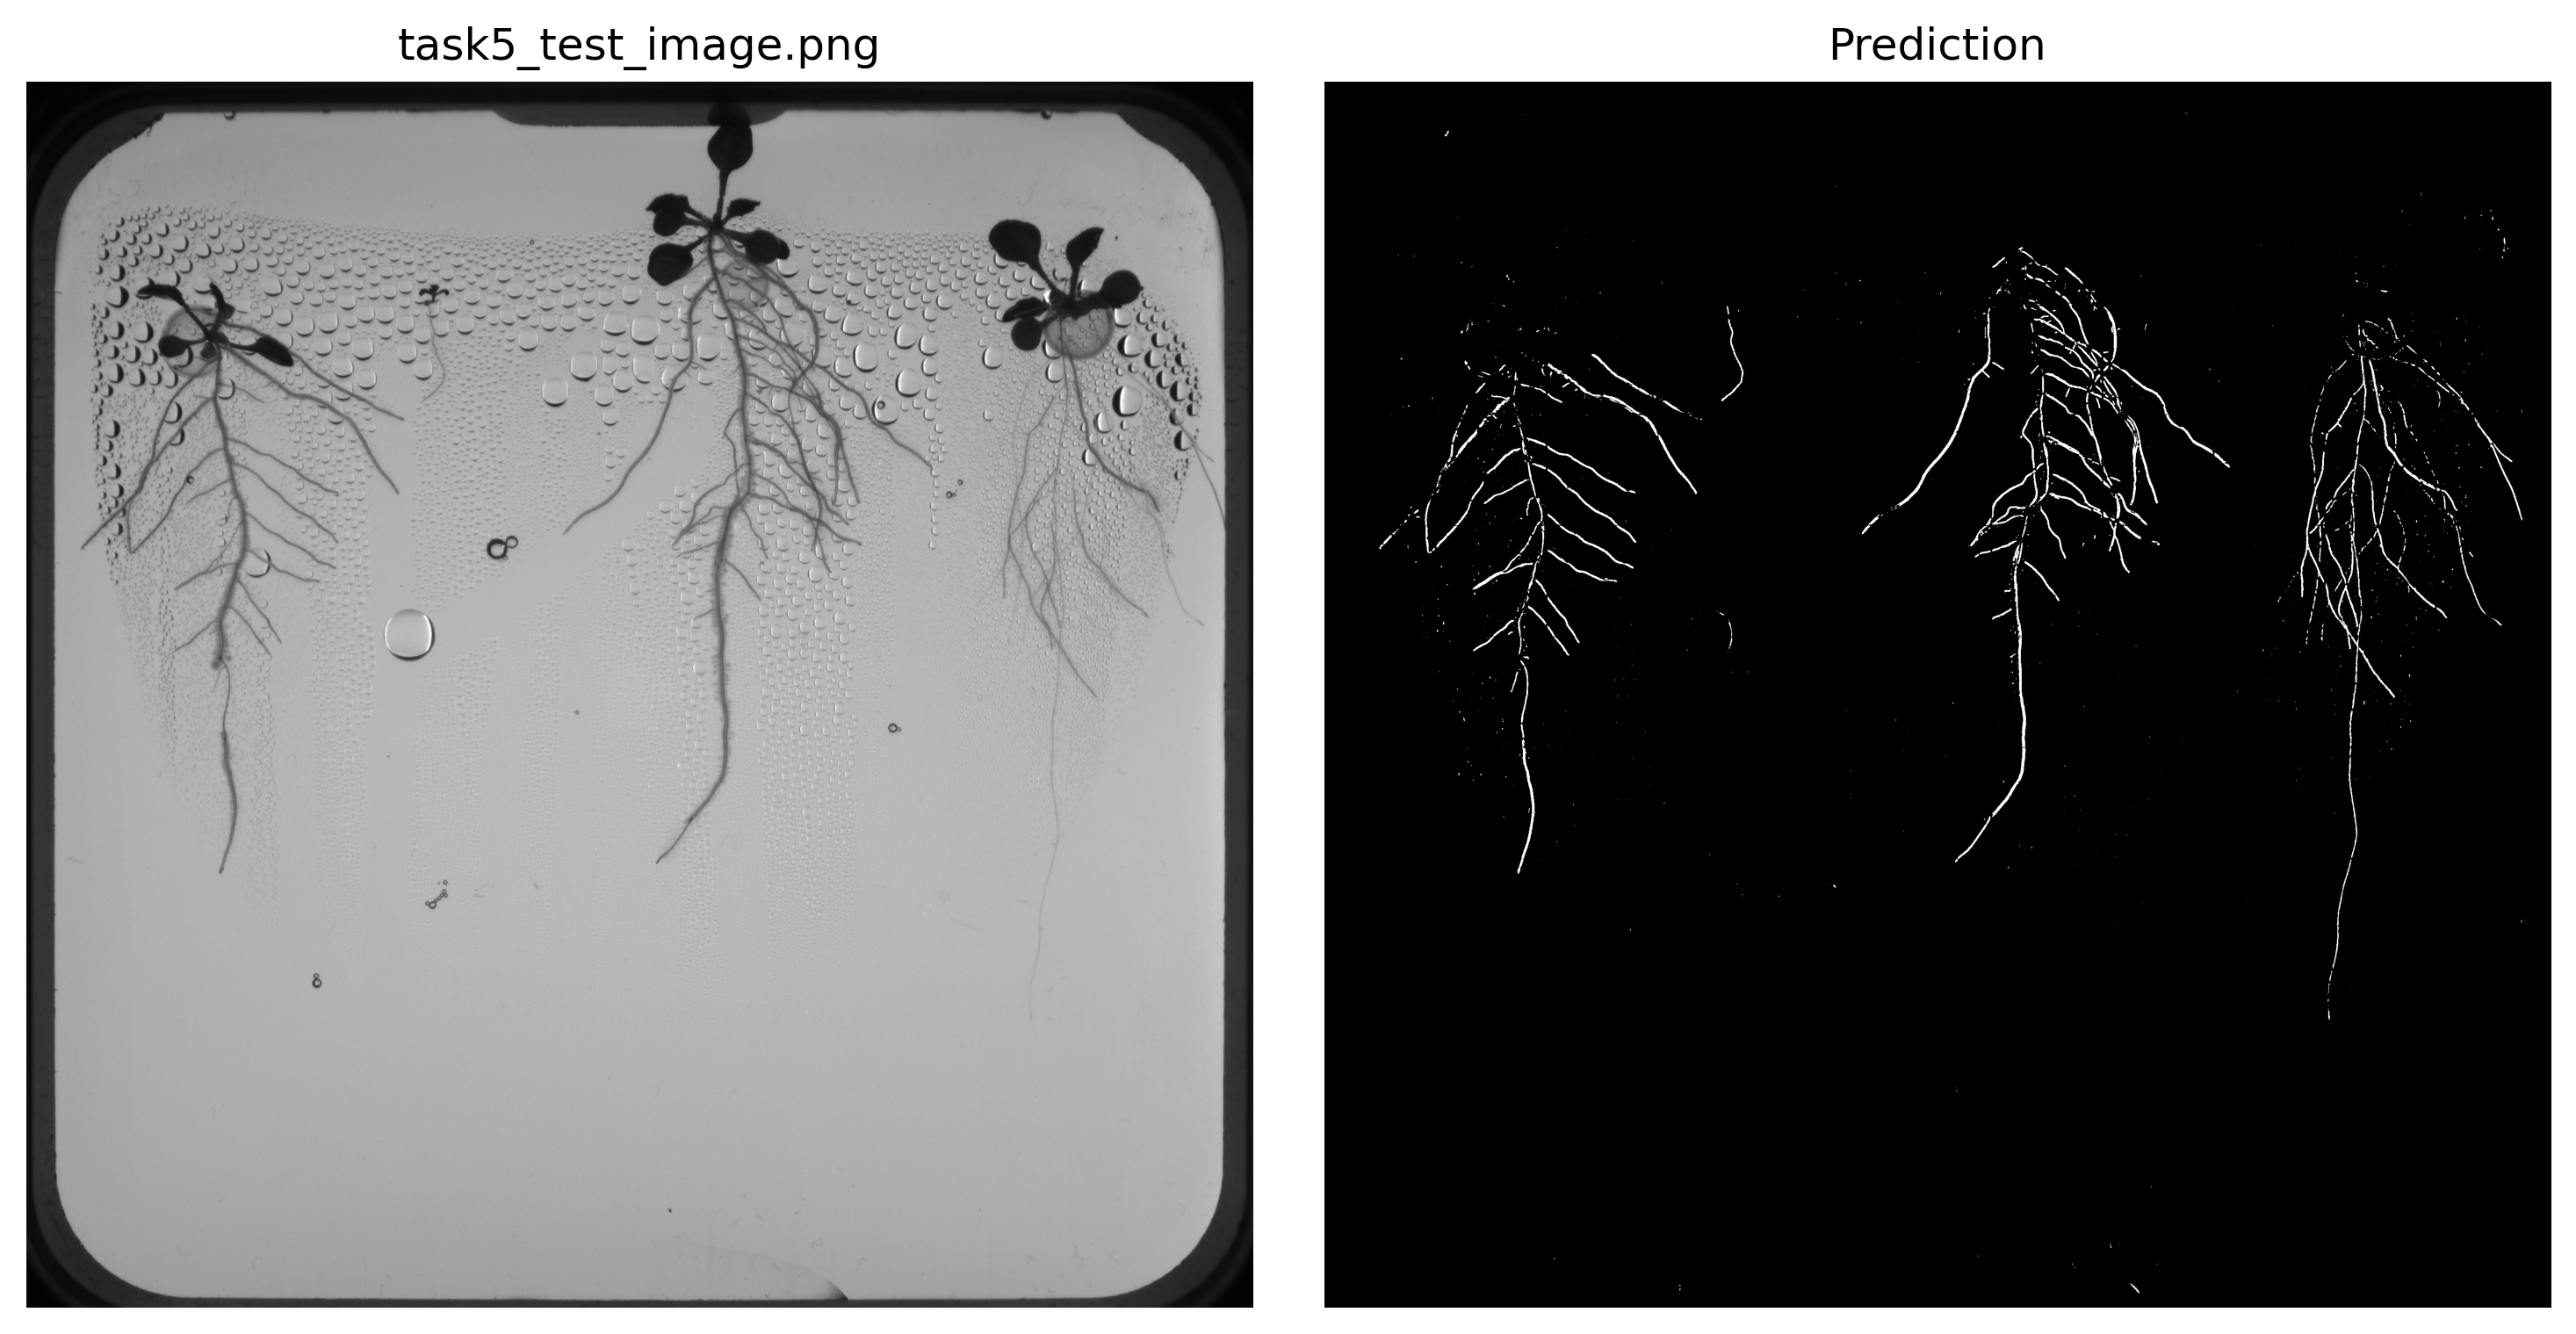

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

# PATCH: Divide the padded Petri dish image into smaller patches
def create_patches(image, patch_size):
    """
    Divide the padded Petri dish image into smaller patches.
    """
    patches = []
    h, w = image.shape
    for i in range(0, h, patch_size):
        for j in range(0, w, patch_size):
            patch = image[i:i + patch_size, j:j + patch_size]
            
            # Pad smaller patches at the edges to the correct patch size
            if patch.shape != (patch_size, patch_size):
                padded_patch = np.zeros((patch_size, patch_size), dtype=image.dtype)
                padded_patch[:patch.shape[0], :patch.shape[1]] = patch
                patch = padded_patch
            
            patches.append(patch)
    return np.array(patches)

# UNPATCH: Combine predicted patches into a single image
def combine_patches(patches, image_shape, patch_size):
    """
    Combine patches into the original padded Petri dish size.
    """
    h, w = image_shape
    reconstructed = np.zeros((h, w), dtype=patches[0].dtype)
    patch_idx = 0

    for i in range(0, h, patch_size):
        for j in range(0, w, patch_size):
            patch_h = min(patch_size, h - i)  # Handle bottom edge
            patch_w = min(patch_size, w - j)  # Handle right edge

            # Resize the patch if necessary to fit into the remaining space
            patch = patches[patch_idx]
            if patch.shape != (patch_h, patch_w):
                patch = cv2.resize(patch, (patch_w, patch_h), interpolation=cv2.INTER_NEAREST)

            reconstructed[i:i + patch_h, j:j + patch_w] = patch
            patch_idx += 1

    return reconstructed

# Predict patches in smaller batches to avoid memory issues
def predict_patches_in_batches(model, patches, batch_size=16):
    """
    Predict patches in smaller batches to avoid memory issues.
    """
    patches = patches / 255.0  # Normalize patches for prediction

    # Convert grayscale patches (1 channel) to RGB (3 channels)
    if len(patches.shape) == 3 or patches.shape[-1] == 1:
        patches = np.stack((patches,) * 3, axis=-1)

    predicted_patches = []
    for i in range(0, len(patches), batch_size):
        batch = patches[i:i + batch_size]
        batch_predictions = model.predict(batch, verbose=1)
        predicted_patches.extend(batch_predictions)
    return np.squeeze((np.array(predicted_patches) > 0.5).astype(np.uint8), axis=-1)

# Define patch size
patch_size = 256

# PATCH: Create patches from the padded Petri dish
patches = create_patches(petri_dish_padded, patch_size)

# PREDICT: Use the trained model to predict the patches in batches
predicted_patches = predict_patches_in_batches(model, patches, batch_size=16)

# UNPATCH: Combine predicted patches into the original padded Petri dish size
predicted_mask = combine_patches(predicted_patches, petri_dish_padded.shape, patch_size)

# Visualize the padded Petri dish and predicted mask
f, ax = plt.subplots(1, 2, dpi=300, figsize=(10, 5))

# Left: Padded Petri dish
ax[0].imshow(petri_dish_padded, cmap='gray')
ax[0].axis('off')
ax[0].set_title('task5_test_image.png')

# Right: Predicted mask
ax[1].imshow(predicted_mask, cmap='gray')
ax[1].axis('off')
ax[1].set_title('Prediction')

plt.tight_layout()
plt.show()


In [10]:
predicted_mask.shape, image.shape

((2826, 2826), (3006, 4112))

As you can see `predicted_mask` and `image` have different shapes. This is because of cropping and padding.

**REQUIREMENT:** The input and output should have the same size and should be aligned perfectly. To achieve this, you need to reverse the effects of cropping and padding added during processing. This will ensure the final mask aligns with the original image.

In [11]:
def align_mask_with_original(predicted_mask, original_shape, coords):
    """
    Align the predicted mask to the original image size by reversing
    the bounding box used during padding/cropping.

    Args:
        predicted_mask (numpy array): Model's predicted mask for the padded region.
        original_shape (tuple): Shape of the original input image (height, width).
        coords (tuple): Bounding box of the padded region in the original image.

    Returns:
        numpy array: Corrected mask aligned to the original image size.
    """
    x1, y1, x2, y2 = coords

    # Create a blank mask with the original shape
    corrected_mask = np.zeros(original_shape, dtype=np.uint8)

    # Ensure predicted_mask dimensions match bounding box dimensions
    expected_height = y2 - y1
    expected_width = x2 - x1

    if predicted_mask.shape != (expected_height, expected_width):
        raise ValueError(f"Predicted mask shape {predicted_mask.shape} does not match bounding box dimensions "
                         f"({expected_height}, {expected_width})")

    # Place the predicted mask in the correct location
    corrected_mask[y1:y2, x1:x2] = predicted_mask

    # Debugging: Print or visualize the corrected mask
    print(f"Corrected Mask Shape: {corrected_mask.shape}")
    return corrected_mask

In [12]:
# Call the function and assign the returned value
predicted_mask_corrected = align_mask_with_original(predicted_mask, image.shape, (x1, y1, x2, y2))

# Debugging: Print to verify it works as expected
print(f"Predicted Mask Corrected Shape: {predicted_mask_corrected.shape}")


Corrected Mask Shape: (3006, 4112)
Predicted Mask Corrected Shape: (3006, 4112)


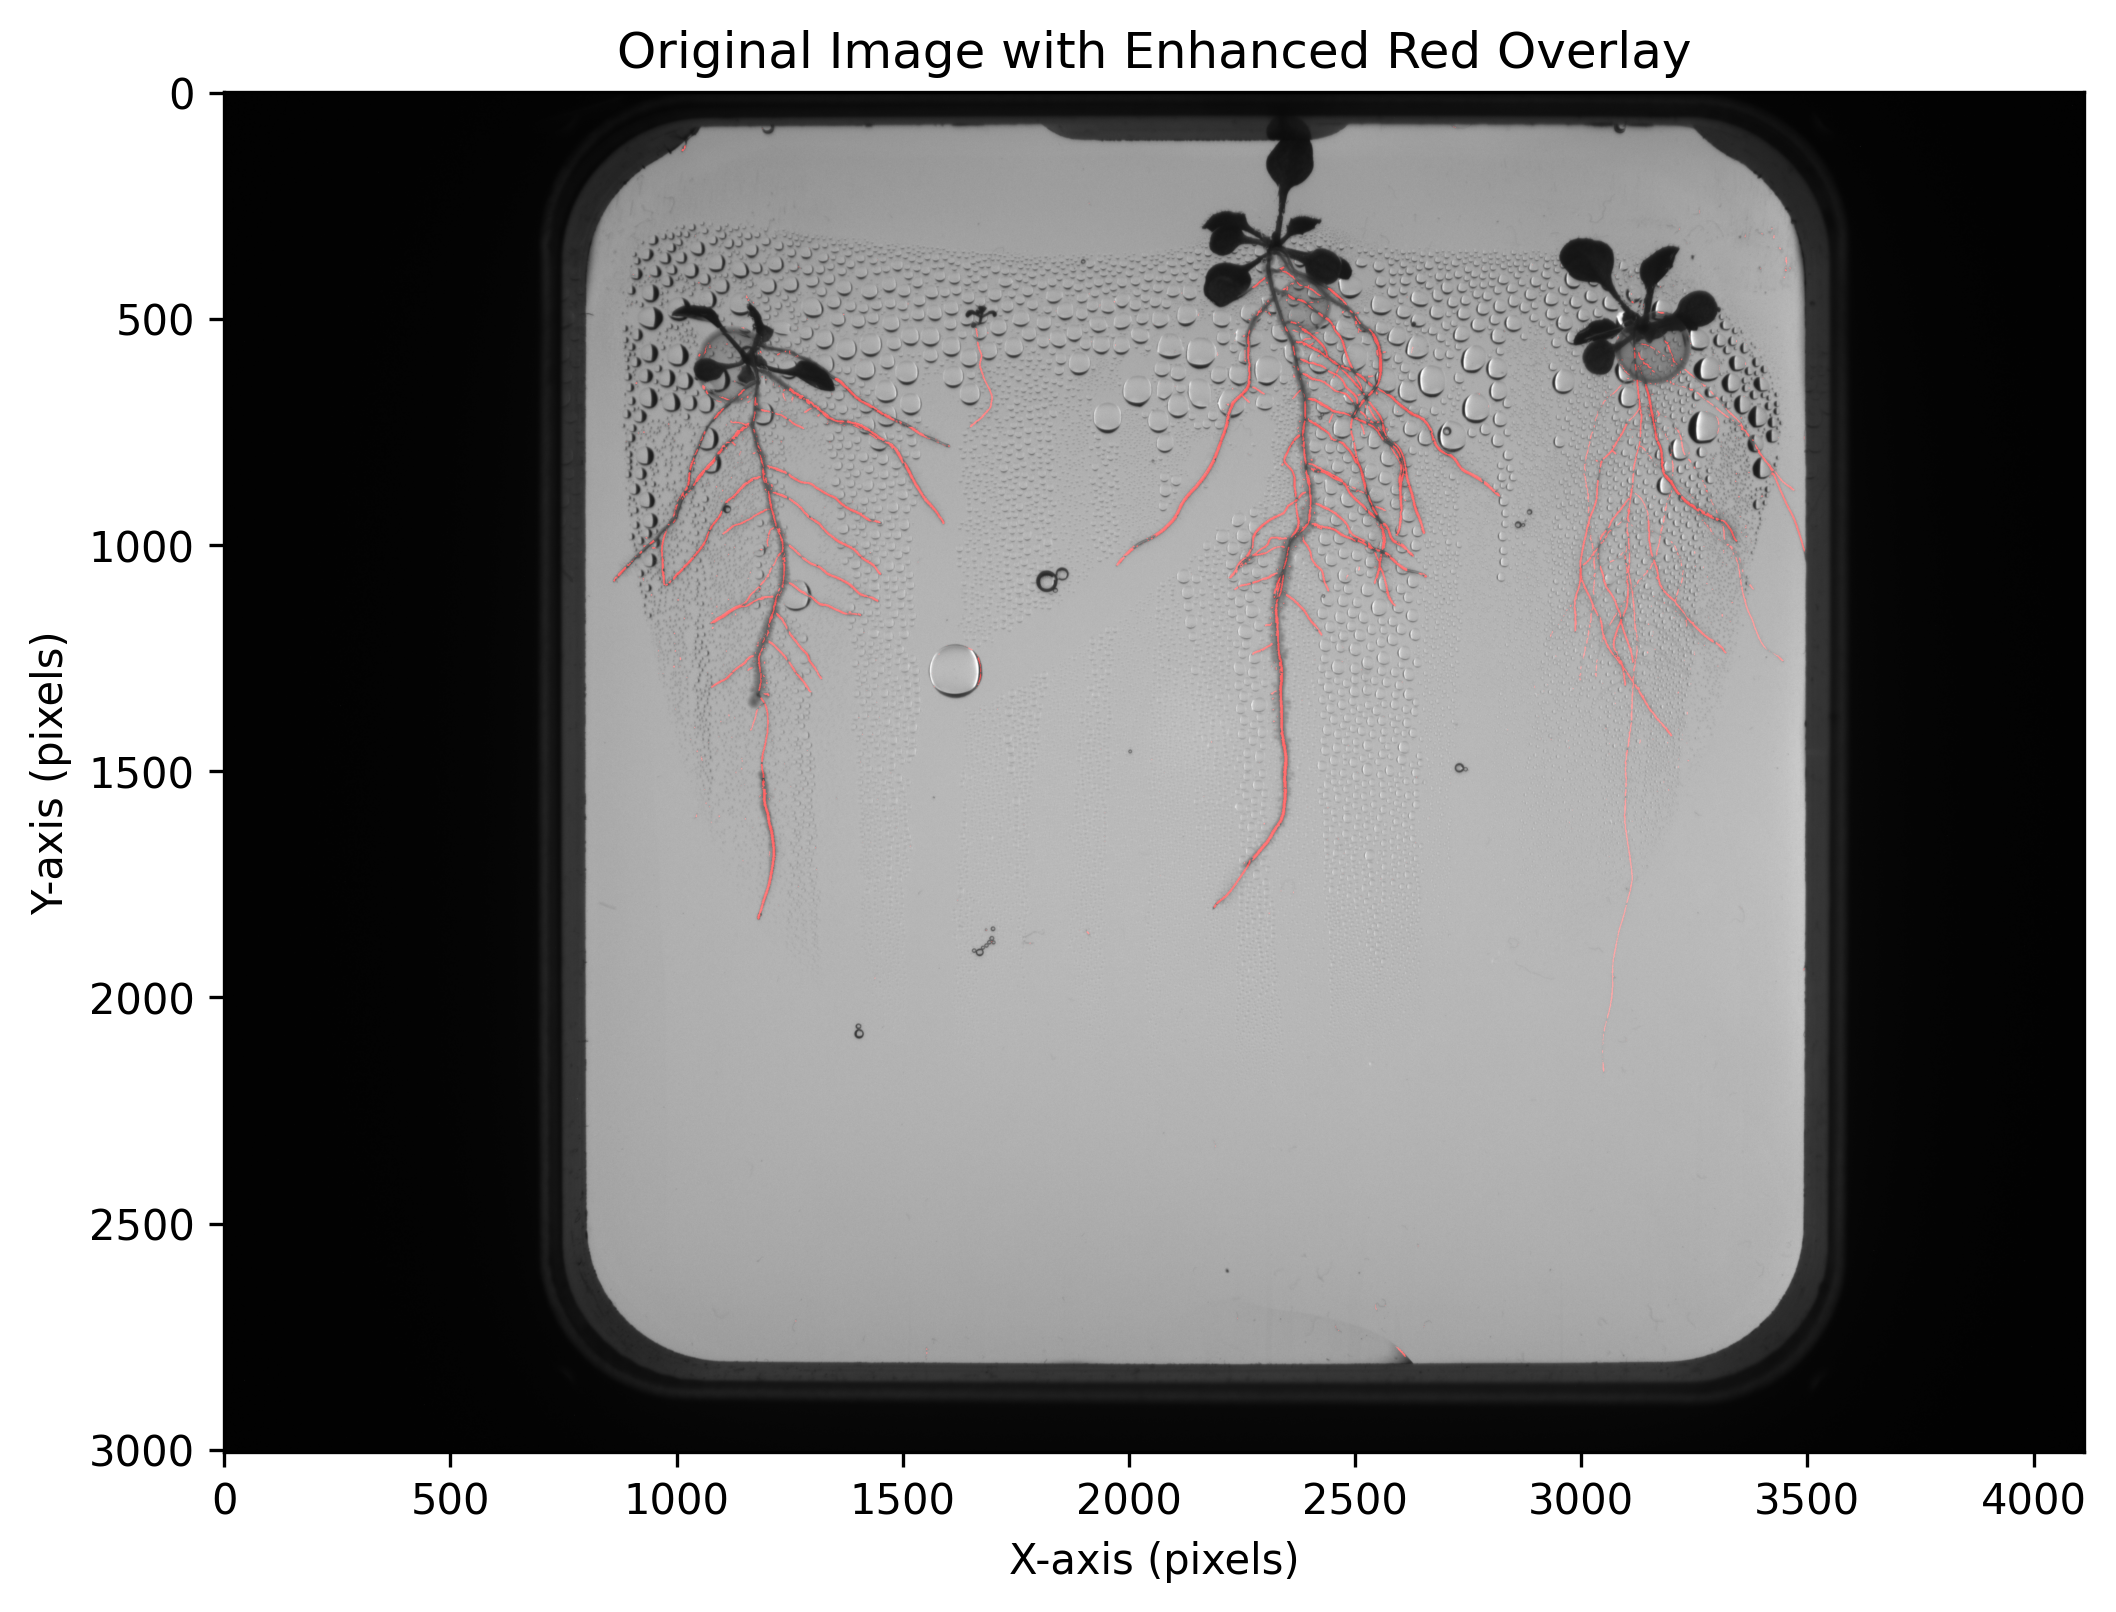

In [13]:
# Convert the grayscale original image to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

# Create a fully saturated red-tinted version of the mask
mask_color = np.zeros_like(image_rgb)  # Create an empty RGB image
mask_color[..., 2] = predicted_mask_corrected * 255  # Fill only the red channel (R in RGB)

# Blend the original image with the red mask (adjust blending weights for more contrast)
alpha = 0.6  # Increase alpha to make the mask more visible
overlay_image = cv2.addWeighted(image_rgb, 1.0, mask_color, alpha, 0)

# Convert to RGB for Matplotlib (OpenCV uses BGR)
overlay_image_rgb = cv2.cvtColor(overlay_image, cv2.COLOR_BGR2RGB)

# Plot the final RGB image with the red overlay and axis ticks
plt.figure(dpi=300, figsize=(8, 6))  # Adjust figure size as needed
plt.imshow(overlay_image_rgb)
plt.title("Original Image with Enhanced Red Overlay")
plt.xlabel("X-axis (pixels)")  # Optional: Label the axes
plt.ylabel("Y-axis (pixels)")
plt.show()


In [14]:
# REQUIREMENT: Save the predicted mask, it is a deliverable.
# REQUIREMENT: Input/Output size must be the same.
# REQUIREMENT: Predicted roots must align with the original image.
# REQUIREMENT: The predicted mask must be binary.
# REQUIREMENT: Non-root pixels must be 0, root pixels must be 255 (unlike Task 1)
# REQUIREMENT: naming convention task5_test_image_prediction_studentname_studentnumber.png
mask_image = (predicted_mask_corrected * 255).astype(np.uint8)
assert(predicted_mask_corrected.shape == image.shape)
cv2.imwrite('task5_test_image_prediction_1_mohamed_233464.png', mask_image)

True

Note: I have trained the model on the Y2B_23 dataset, since there are no labels for Y2B_24 dataset yet. The test image is from Y2B_24, this is why the predicted mask is suboptimal. Therefore do not take the performance of this prediction as a reference. Your predictions should be much better than this.